# Анализ мультиомиксных данных
## Цель проекта

Расширить базовый анализ по предсказанию выживаемости на основе мультиомиксных данных путём добавления дополнительных методов интеграции и варьирования параметров существующих моделей.

## Задачи проекта

1. **MOFA (slow convergence):** Запустить MOFA с параметром `convergence_mode='slow'` и сравнить качество с базовым вариантом (`fast`).
2. **Оптимизация эпох автоэнкодера:** Эмпирически подобрать оптимальное количество эпох обучения автоэнкодера для максимизации MAPE и C-index.
3. **UMAP:** Добавить UMAP как метод интеграции мультиомиксных данных.
4. **Модифицированная архитектура автоэнкодера:** Реализовать автоэнкодер с раздельными энкодерами для каждой модальности.
5. **(\*)** Описать архитектуру модифицированного автоэнкодера.

## Данные

Мультиомиксные данные по раку молочной железы из TCGA:
- Транскриптомные данные (exp), метилирование (methy), микроРНК (mirna)
- Данные о выживаемости (survival) и клинические данные (clinical)

---
## 1. Установка библиотек и импорт

Устанавливаем необходимые библиотеки: mofapy2 для MOFA, catboost для регрессии, scikit-survival для C-index, mofax для визуализации весов MOFA, umap-learn для UMAP.

In [ ]:
import os, sys
os.system("pip install mofapy2 datasets catboost scikit-survival mofax umap-learn")

0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, random, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sksurv.metrics import concordance_index_censored
from catboost import CatBoostRegressor

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from datasets import Dataset
import h5py, umap

os.environ['WANDB_DISABLED'] = 'true'
RANDOM_STATE = 42
N_FACTORS = 20

---
## 2. Загрузка и подготовка данных

Загружаем архивы с мультиомиксными и клиническими данными.

In [ ]:
import zipfile
for archive in ['breast.zip', 'clinical.zip']:
    with zipfile.ZipFile(archive, 'r') as z:
        z.extractall('.')

### 2.1. Функции предобработки данных

In [ ]:
def handle_duplicates(df):
    inconsistent = []
    for pid, group in df.groupby('PatientID'):
        if group['Death'].nunique() > 1:
            inconsistent.append(pid)
    if inconsistent:
        df = df[~df['PatientID'].isin(inconsistent)]
    else:
        df = df.drop_duplicates(subset='PatientID')
    return df

def prepare_survival_data(path, id_sep='.'):
    survival = pd.read_csv(path, sep='\t')
    survival['PatientID'] = survival['PatientID'].str.lower()
    if id_sep == '-':
        survival['PatientID'] = survival['PatientID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
        survival['PatientID'] = survival['PatientID'].str.replace('-', '.')
    survival = handle_duplicates(survival)
    survival = survival.dropna(subset=['Death'])
    return survival.set_index('PatientID').sort_index()

def prepare_data(path, patient_ids=None):
    data = pd.read_csv(path, sep=' ').T
    data.index = data.index.str.lower().str.replace(r'\.01$', '', regex=True)
    if patient_ids is not None:
        data = data[data.index.isin(patient_ids)]
    return data.sort_index()

def preprocess_data_for_mofa(df):
    columns_all_zeros = ~df.all(axis=0)
    df = df.loc[:, ~columns_all_zeros]
    variances = df.var()
    df = df.loc[:, variances != 0]
    threshold = variances.quantile(0.95)
    df = df[variances[variances <= threshold].index]
    return pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index)

def choose_common_patients(dfs):
    common = set(dfs[0].index)
    for d in dfs[1:]:
        common &= set(d.index)
    return [d[d.index.isin(common)] for d in dfs]

def transform_df_for_mofa(df, view):
    df = df.copy()
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'sample'}, inplace=True)
    melted = df.melt(id_vars='sample', var_name='feature', value_name='value')
    melted['view'] = view
    return melted

### 2.2. Загрузка и предобработка данных

In [ ]:
survival_data_breast = prepare_survival_data('breast/survival')
print(f'Пациенты с данными о выживаемости: {survival_data_breast.shape[0]}')
survival_data_breast.head()

Пациенты с данными о выживаемости: 1095


,Survival,Death
PatientID,,
tcga.3c.aaau,4047.0,0.0
tcga.3c.aali,4005.0,0.0
tcga.3c.aalj,1474.0,0.0
tcga.3c.aalk,1448.0,0.0
tcga.4h.aaak,348.0,0.0


In [ ]:
patient_ids = survival_data_breast.index
expression = prepare_data('breast/exp', patient_ids)
methylation = prepare_data('breast/methy', patient_ids)
mirna = prepare_data('breast/mirna', patient_ids)

expression = preprocess_data_for_mofa(expression)
methylation = preprocess_data_for_mofa(methylation)
mirna = preprocess_data_for_mofa(mirna)

survival_data_breast, expression, methylation, mirna = choose_common_patients(
    [survival_data_breast, expression, methylation, mirna])
expression = expression.dropna(axis=1)
methylation = methylation.dropna(axis=1)
mirna = mirna.dropna(axis=1)

os.makedirs('data/outputs', exist_ok=True)
expression.to_csv('data/outputs/expression_breast.csv')
methylation.to_csv('data/outputs/methylation_breast.csv')
mirna.to_csv('data/outputs/mirna_breast.csv')

print(f'Expression: {expression.shape}, Methylation: {methylation.shape}, miRNA: {mirna.shape}')
print(f'Survival: {survival_data_breast.shape}, Пациенты: {expression.shape[0]}')

Expression: (620, 1280), Methylation: (620, 1148), miRNA: (620, 182)
Survival: (620, 2), Пациенты: 620


In [ ]:
exp_melted = transform_df_for_mofa(expression, 'expression')
met_melted = transform_df_for_mofa(methylation, 'methylation')
mir_melted = transform_df_for_mofa(mirna, 'mirna')
mofa_data_breast = pd.concat([exp_melted, met_melted, mir_melted], axis=0)
mofa_data_breast['group'] = 'breast'
print(f'MOFA data shape: {mofa_data_breast.shape}')

MOFA data shape: (1618200, 5)


In [ ]:
X_breast_all = np.hstack([expression.values, methylation.values, mirna.values])
print(f'X_breast_all: {X_breast_all.shape}')

X_breast_all: (620, 2610)


In [ ]:
clinical_data = pd.read_csv('clinical/breast', sep='\t')
clinical_data.index = clinical_data.index.map(
    lambda x: survival_data_breast.index[x] if x < len(survival_data_breast) else None)

CATEGORICAL_CLINICAL = [
    'anatomic_neoplasm_subdivision', 'axillary_lymph_node_stage_method_type',
    'breast_carcinoma_estrogen_receptor_status', 'breast_carcinoma_progesterone_receptor_status',
    'breast_carcinoma_surgical_procedure_name', 'gender', 'histological_type',
    'history_of_neoadjuvant_treatment', 'icd_10', 'icd_o_3_histology', 'icd_o_3_site',
    'initial_pathologic_diagnosis_method', 'lab_proc_her2_neu_immunohistochemistry_receptor_status',
    'margin_status', 'menopause_status', 'new_tumor_event_after_initial_treatment',
    'oct_embedded', 'pathologic_M', 'pathologic_N', 'pathologic_T', 'pathologic_stage',
    'person_neoplasm_cancer_status', 'primary_lymph_node_presentation_assessment',
    'radiation_therapy', 'system_version', 'tissue_prospective_collection_indicator',
    'tissue_retrospective_collection_indicator', 'tissue_source_site']
NUMERICAL_CLINICAL = ['age_at_initial_pathologic_diagnosis', 'initial_weight',
                      'lymph_node_examined_count', 'number_of_lymphnodes_positive_by_he']
CLINICAL_FEATURES = NUMERICAL_CLINICAL + CATEGORICAL_CLINICAL
N_NUMERIC_CLINICAL = len(NUMERICAL_CLINICAL)

clinical_features = clinical_data[CLINICAL_FEATURES].copy()
for col in CATEGORICAL_CLINICAL:
    clinical_features[col] = clinical_features[col].fillna('missing')
print(f'Клинические признаки: {clinical_features.shape}')

Клинические признаки: (1247, 32)


In [ ]:
def split_patients_for_target_prediction(target_df, test_size=0.25, random_state=42, stratify_by=None):
    indices = np.arange(len(target_df))
    strat = target_df[stratify_by].values if stratify_by else None
    return train_test_split(indices, test_size=test_size, random_state=random_state, stratify=strat)

TRAIN_INDICES, TEST_INDICES = split_patients_for_target_prediction(survival_data_breast, stratify_by='Death')
print(f'Train: {len(TRAIN_INDICES)}, Test: {len(TEST_INDICES)}')

Train: 465, Test: 155


---
## 3. Регрессионный пайплайн

Функция `regression_pipeline` строит CatBoost-регрессор для предсказания survival и вычисляет MAPE и C-index.

In [ ]:
def regression_pipeline(factors, clinical_features, survival_data_breast, TRAIN_INDICES, TEST_INDICES,
                        RANDOM_STATE, N_FACTORS, N_NUMERIC_CLINICAL, CLINICAL_FEATURES,
                        plot_feat_imp=True, method_name=''):
    combined_df = pd.concat([pd.DataFrame(factors), clinical_features.reset_index(drop=True)], axis=1)
    cat_idx = list(range(N_FACTORS + N_NUMERIC_CLINICAL, combined_df.shape[1]))
    factors_df = pd.DataFrame(factors)
    X_tr, X_te = combined_df.values[TRAIN_INDICES], combined_df.values[TEST_INDICES]
    X_tr_f, X_te_f = factors_df.values[TRAIN_INDICES], factors_df.values[TEST_INDICES]
    y_tr = survival_data_breast['Survival'].values[TRAIN_INDICES]
    y_te = survival_data_breast['Survival'].values[TEST_INDICES]

    cb_f = CatBoostRegressor(n_estimators=1000, random_state=RANDOM_STATE, silent=True)
    cb_f.fit(X_tr_f, y_tr); y_pred_f = cb_f.predict(X_te_f)
    cb_c = CatBoostRegressor(n_estimators=1000, random_state=RANDOM_STATE, silent=True, cat_features=cat_idx)
    cb_c.fit(X_tr, y_tr); y_pred_c = cb_c.predict(X_te)

    event = survival_data_breast['Death'].values[TEST_INDICES].astype(bool)
    metrics = {
        'MAPE_f': mean_absolute_percentage_error(y_te, y_pred_f) * 100,
        'MAPE_f_c': mean_absolute_percentage_error(y_te, y_pred_c) * 100,
        'C-index_f': concordance_index_censored(event, y_te, 1/y_pred_f)[0],
        'C-index_f_c': concordance_index_censored(event, y_te, 1/y_pred_c)[0],
    }
    if not plot_feat_imp:
        return metrics

    from matplotlib.patches import Patch
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sfx = f' ({method_name})' if method_name else ''
    fi_f = cb_f.get_feature_importance()
    imp_f = pd.DataFrame({'Feature': [f'Factor {i+1}' for i in range(len(fi_f))], 'Importance': fi_f})
    imp_f = imp_f.sort_values('Importance', ascending=True)
    axes[0].barh(imp_f['Feature'], imp_f['Importance'], color='steelblue')
    axes[0].set_xlabel('Importance'); axes[0].set_title(f'Feature Importance (факторы){sfx}')

    fi_c = cb_c.get_feature_importance()
    names_c = [f'Factor {i+1}' for i in range(N_FACTORS)] + list(CLINICAL_FEATURES)
    imp_c = pd.DataFrame({'Feature': names_c, 'Importance': fi_c})
    imp_c = imp_c.sort_values('Importance', ascending=False).head(25).sort_values('Importance', ascending=True)
    colors = ['indianred' if f.startswith('Factor') else 'steelblue' for f in imp_c['Feature']]
    axes[1].barh(imp_c['Feature'], imp_c['Importance'], color=colors)
    axes[1].set_xlabel('Importance'); axes[1].set_title(f'Feature Importance (ф+клиника, Top-25){sfx}')
    axes[1].legend(handles=[Patch(facecolor='indianred', label='Факторы'),
                            Patch(facecolor='steelblue', label='Клинические')], loc='lower right')
    plt.tight_layout(); plt.show()
    return metrics

pipeline_args = (clinical_features, survival_data_breast, TRAIN_INDICES, TEST_INDICES,
                 RANDOM_STATE, N_FACTORS, N_NUMERIC_CLINICAL, CLINICAL_FEATURES)

---
## 4. Базовые методы интеграции (для сравнения)

Получаем базовые результаты с помощью MOFA (fast), PCA и автоэнкодера.

### 4.1. MOFA (fast) — базовый вариант

In [ ]:
from mofapy2.run.entry_point import entry_point

def train_mofa(data_df, random_state=42, factors=10,
               train_params={'iter': 5000, 'convergence_mode': 'fast'}):
    ent = entry_point()
    ent.set_data_options(scale_views=False)
    ent.set_data_df(data_df)
    ent.set_model_options(factors=factors, ard_factors=True)
    ent.set_train_options(**train_params, gpu_mode=False, seed=random_state, quiet=True)
    ent.build(); ent.run()
    outfile = f"data/outputs/mofa_{train_params.get('convergence_mode','default')}_{time.time()}.hdf5"
    ent.save(outfile, save_data=True)
    return ent.model.nodes['Z'].getExpectation(), ent.model.nodes['W'].getExpectation(), ent.model.calculate_variance_explained(), outfile

In [ ]:
mofa_fast_factors, mofa_fast_weights, mofa_fast_r2, mofa_fast_file = train_mofa(
    mofa_data_breast, random_state=RANDOM_STATE, factors=N_FACTORS,
    train_params={'iter': 5000, 'convergence_mode': 'fast'})
print(f'MOFA (fast) factors shape: {mofa_fast_factors.shape}')


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Loaded group='breast' view='expression' with N=620 samples and D=1280 features...
Loaded group='breast' view='methylation' with N=620 samples and D=1148 features...
Loaded group='breast' view='mirna' with N=620 samples and D=182 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- 

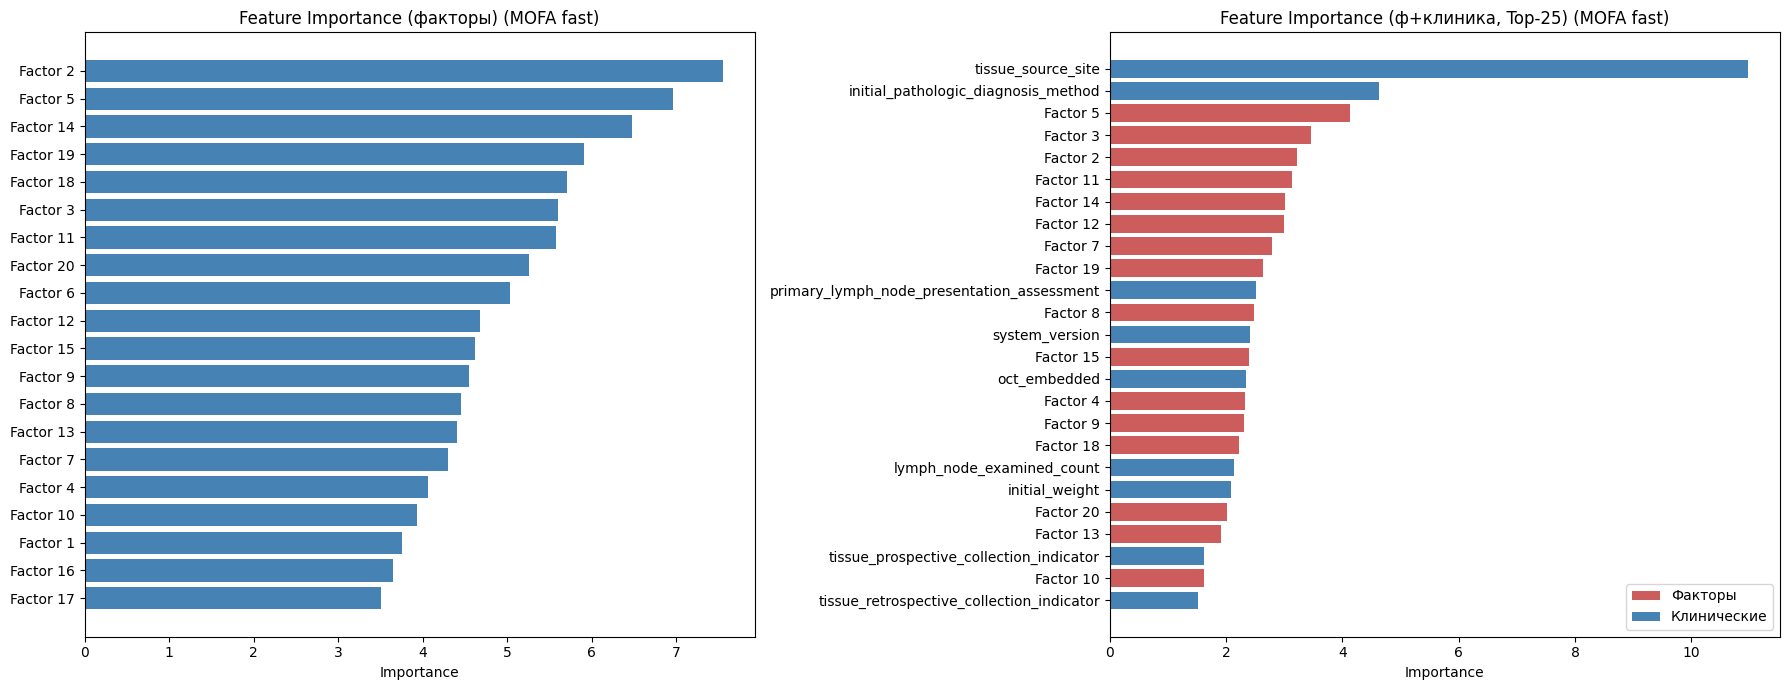


Метрики MOFA (fast):
  MAPE_f: 141.8447
  MAPE_f_c: 128.8053
  C-index_f: 0.6779
  C-index_f_c: 0.5946


In [ ]:
mofa_fast_metrics = regression_pipeline(mofa_fast_factors, *pipeline_args, method_name='MOFA fast')
print('\nМетрики MOFA (fast):')
for k, v in mofa_fast_metrics.items():
    print(f'  {k}: {v:.4f}')

#### Визуализация весов MOFA

Тепловая карта весов показывает, какие признаки вносят наибольший вклад в каждый фактор.

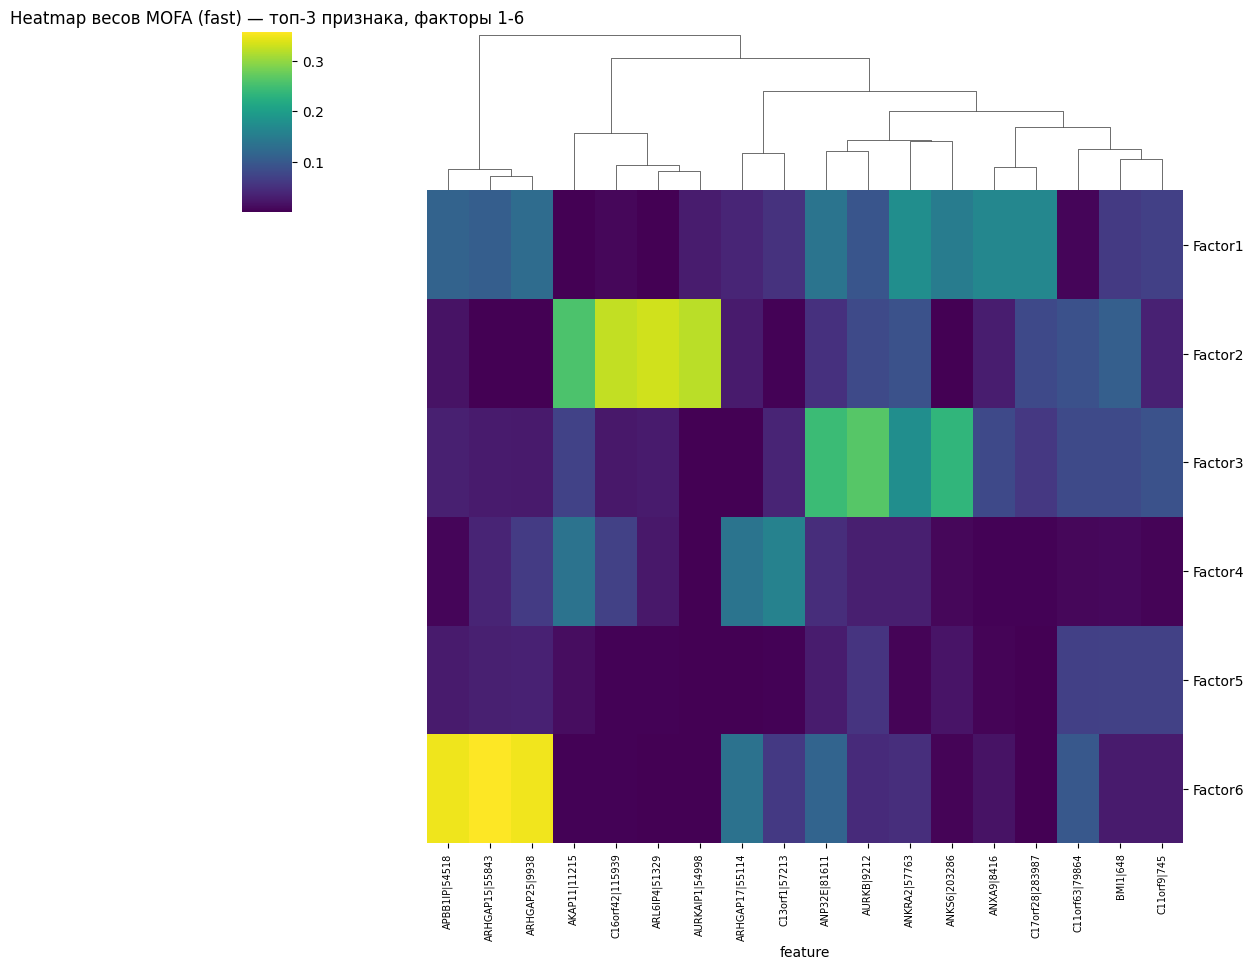

In [ ]:
import mofax as mfx
m = mfx.mofa_model(mofa_fast_file)
mfx.plot_weights_heatmap(m, n_features=3, factors=range(0, 6),
                         xticklabels_size=7, w_abs=True, cmap='viridis', cluster_factors=False)
plt.title('Heatmap весов MOFA (fast) — топ-3 признака, факторы 1-6')
plt.show()

### 4.2. PCA — базовый вариант

PCA: (620, 20), объяснённая дисперсия: 0.4883


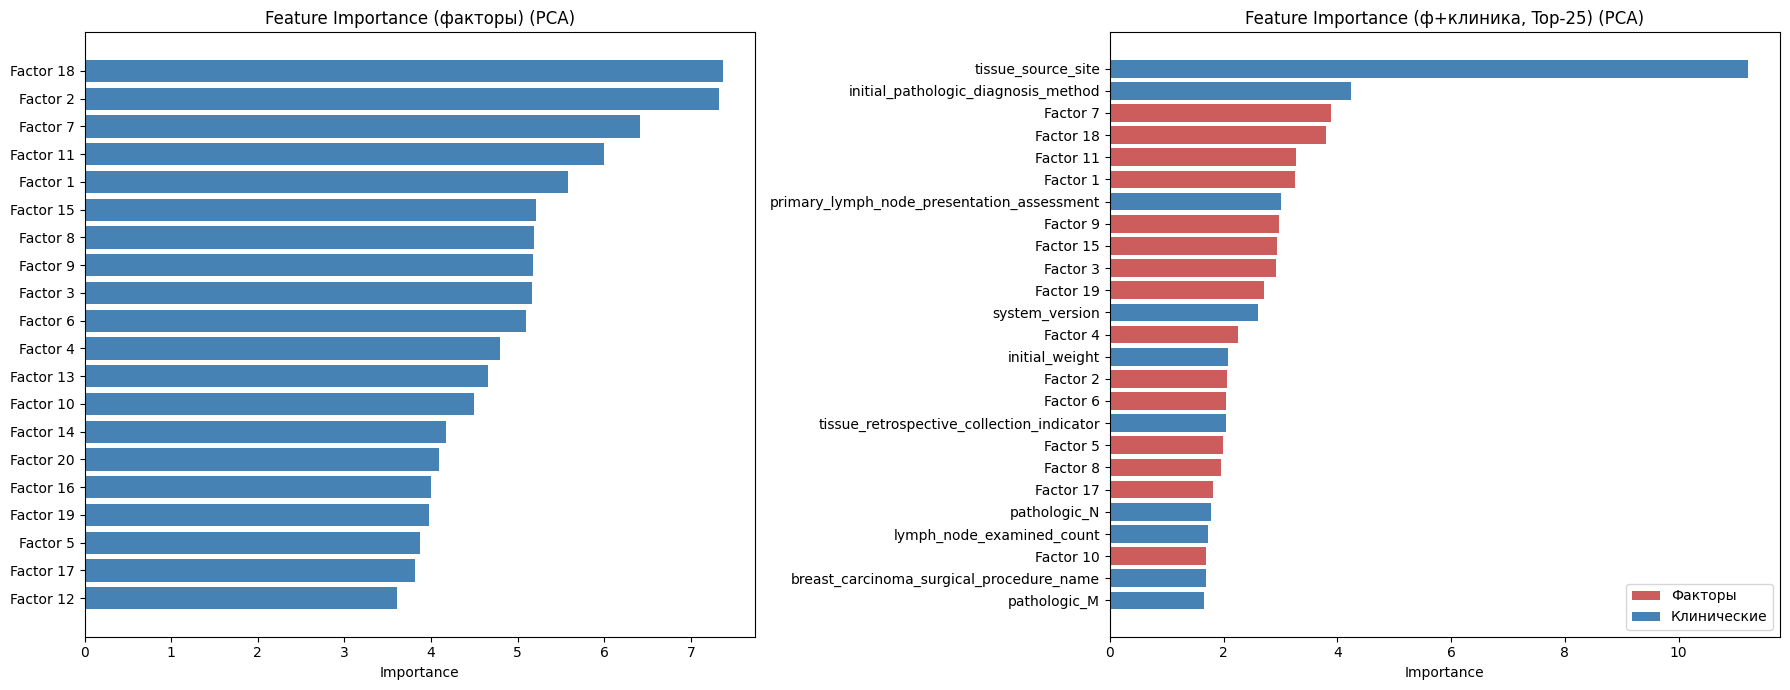


Метрики PCA:
  MAPE_f: 127.6617
  MAPE_f_c: 121.7640
  C-index_f: 0.6792
  C-index_f_c: 0.6154


In [ ]:
pca = PCA(n_components=N_FACTORS, random_state=RANDOM_STATE)
pca_factors = pca.fit_transform(X_breast_all)
print(f'PCA: {pca_factors.shape}, объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.4f}')

pca_metrics = regression_pipeline(pca_factors, *pipeline_args, method_name='PCA')
print('\nМетрики PCA:')
for k, v in pca_metrics.items():
    print(f'  {k}: {v:.4f}')

### 4.3. Автоэнкодер (базовый, 50 эпох)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dims, n_out):
        super().__init__()
        hidden_dim = sum(input_dims)
        self.encoder = nn.Sequential(nn.Linear(hidden_dim, 128), nn.Tanh(), nn.Dropout(0.5))
        self.bottleneck = nn.Linear(128, n_out)
        self.decoder = nn.Sequential(nn.Linear(n_out, hidden_dim))
    def forward(self, inputs):
        x = torch.cat(inputs, dim=1)
        return self.decoder(self.bottleneck(self.encoder(x)))
    def encode(self, inputs):
        x = torch.cat(inputs, dim=1)
        return self.bottleneck(self.encoder(x))

class EncoderPipeline:
    def __init__(self, modalities, n_out, random_state):
        self.modalities = modalities; self.random_state = random_state
        self.input_dims = [m.shape[1] for m in modalities]
        self.model = Autoencoder(self.input_dims, n_out)
        self.device = torch.device('cpu')
        self.train_loader = self._loader(modalities); self.loss_history = []
    def _loader(self, mods):
        return DataLoader(TensorDataset(*[torch.tensor(m, dtype=torch.float32) for m in mods]), batch_size=32, shuffle=False)
    def fit(self, n_epochs=50):
        random.seed(self.random_state); np.random.seed(self.random_state); torch.manual_seed(self.random_state)
        self.model.to(self.device); opt = optim.AdamW(self.model.parameters(), lr=0.001); crit = nn.MSELoss()
        self.loss_history = []
        for ep in range(n_epochs):
            self.model.train(); rl = 0.0
            for data in self.train_loader:
                inp = [m.to(self.device) for m in data]; tgt = torch.cat(inp, dim=1)
                opt.zero_grad(); loss = crit(self.model(inp), tgt); loss.backward(); opt.step(); rl += loss.item()
            self.loss_history.append(rl)
            if (ep+1) % 25 == 0 or ep == 0: print(f'  Epoch {ep+1}/{n_epochs}, Loss: {rl:.4f}')
    def transform(self, mods=None):
        self.model.eval(); out = []
        loader = self.train_loader if mods is None else self._loader(mods)
        with torch.no_grad():
            for data in loader:
                inp = [m.to(self.device) for m in data]; out.append(self.model.encode(inp).cpu())
        return np.vstack(out)

In [ ]:
modalities = [expression.values, methylation.values, mirna.values]
enc_pipeline = EncoderPipeline(modalities, N_FACTORS, RANDOM_STATE)
enc_pipeline.fit(n_epochs=50)
ae_base_factors = enc_pipeline.transform()
print(f'\nAutoencoder factors: {ae_base_factors.shape}')

  Epoch 1/50, Loss: 22.0034
  Epoch 25/50, Loss: 13.9159
  Epoch 50/50, Loss: 13.1886

Autoencoder factors: (620, 20)


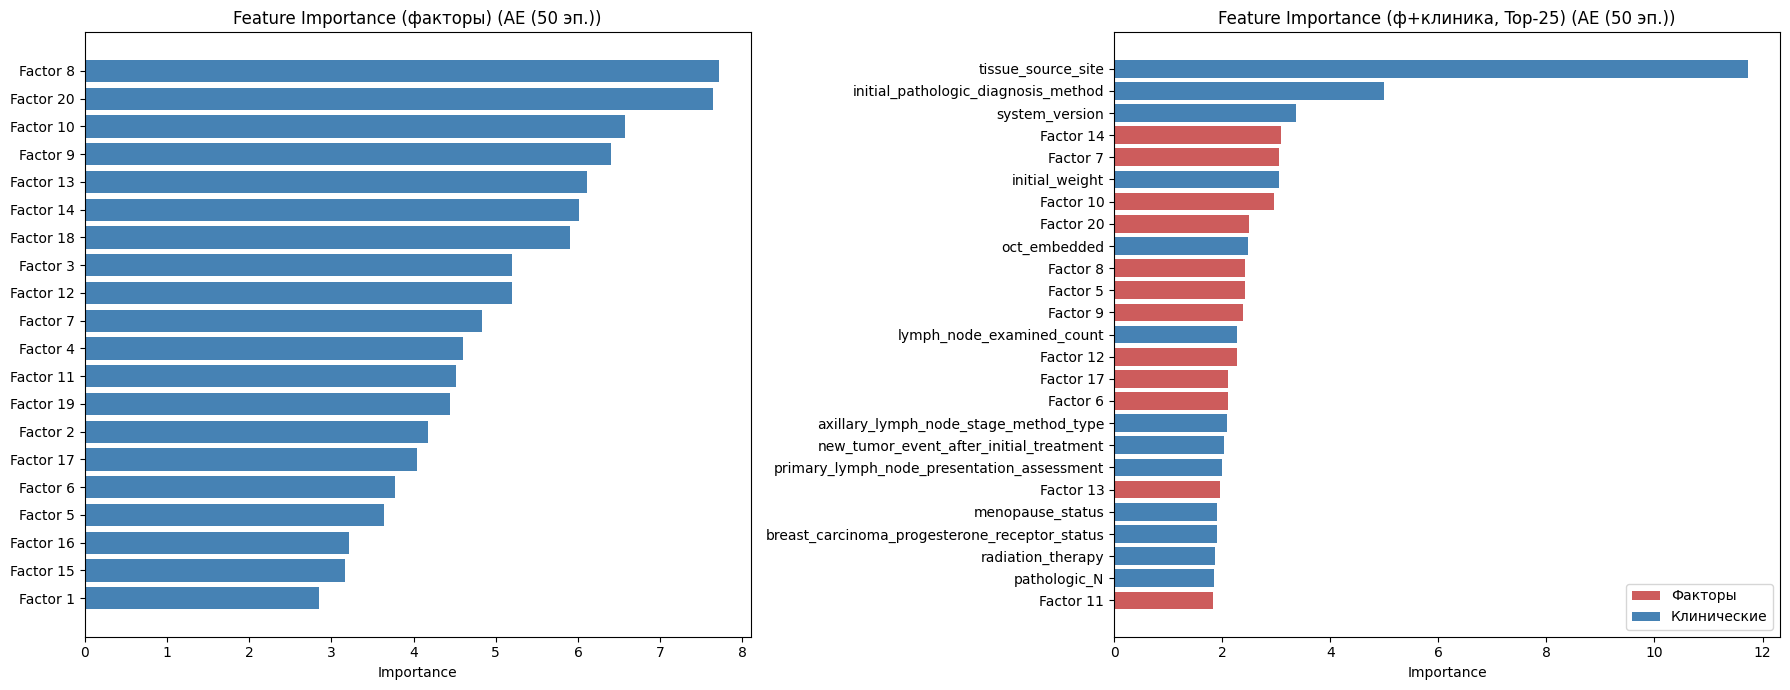


Метрики AE (50 эпох):
  MAPE_f: 138.4735
  MAPE_f_c: 122.1444
  C-index_f: 0.6644
  C-index_f_c: 0.6040


In [ ]:
ae_base_metrics = regression_pipeline(ae_base_factors, *pipeline_args, method_name='AE (50 эп.)')
print('\nМетрики AE (50 эпох):')
for k, v in ae_base_metrics.items():
    print(f'  {k}: {v:.4f}')

---
## 5. Эксперимент 1: MOFA с convergence_mode='slow'

Запускаем MOFA с `convergence_mode='slow'`. В режиме slow оптимизация происходит более тщательно.

In [ ]:
mofa_slow_factors, _, _, mofa_slow_file = train_mofa(
    mofa_data_breast, random_state=RANDOM_STATE, factors=N_FACTORS,
    train_params={'iter': 5000, 'convergence_mode': 'slow'})
print(f'MOFA (slow) factors: {mofa_slow_factors.shape}')


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Loaded group='breast' view='expression' with N=620 samples and D=1280 features...
Loaded group='breast' view='methylation' with N=620 samples and D=1148 features...
Loaded group='breast' view='mirna' with N=620 samples and D=182 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- 

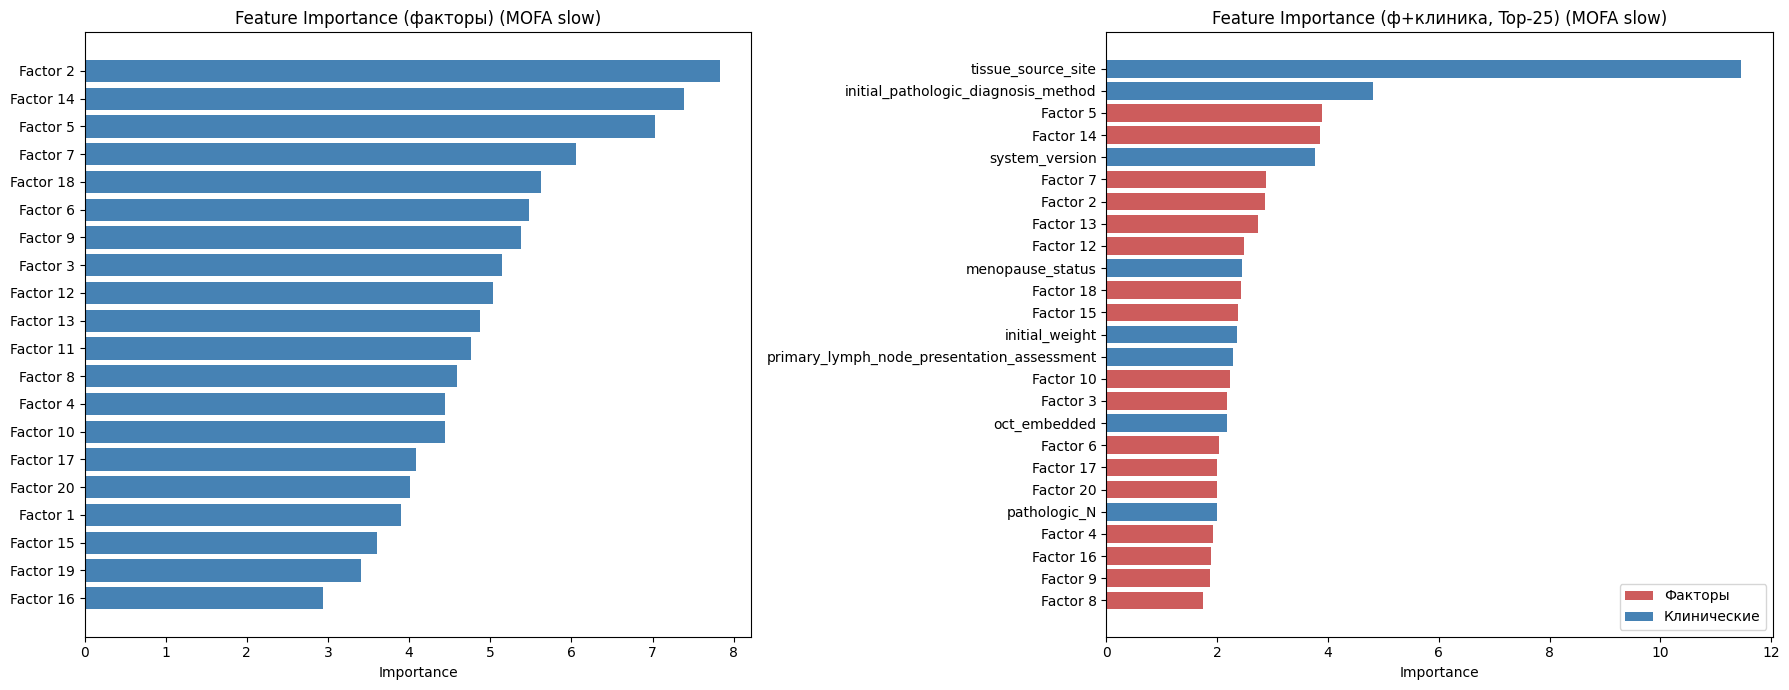


Метрики MOFA (slow):
  MAPE_f: 138.2511
  MAPE_f_c: 124.0296
  C-index_f: 0.6161
  C-index_f_c: 0.6027


In [ ]:
mofa_slow_metrics = regression_pipeline(mofa_slow_factors, *pipeline_args, method_name='MOFA slow')
print('\nМетрики MOFA (slow):')
for k, v in mofa_slow_metrics.items():
    print(f'  {k}: {v:.4f}')

### Сравнение MOFA fast vs slow

In [ ]:
mofa_cmp = pd.DataFrame({'MOFA (fast)': mofa_fast_metrics, 'MOFA (slow)': mofa_slow_metrics}).T
mofa_cmp.columns = ['MAPE (факторы)', 'MAPE (ф+клиника)', 'C-index (факторы)', 'C-index (ф+клиника)']
mofa_cmp

,MAPE (факторы),MAPE (ф+клиника),C-index (факторы),C-index (ф+клиника)
MOFA (fast),141.844720,128.805332,0.677852,0.594631
MOFA (slow),138.251064,124.029573,0.616107,0.602685


**Анализ результатов (MOFA fast vs slow):**

Сравнение двух режимов сходимости MOFA:

| Метрика | MOFA (fast) | MOFA (slow) | Изменение |
|---------|-------------|-------------|----------|
| MAPE (факторы) | 141.84% | 138.25% | −3.59 п.п. (улучшение) |
| MAPE (ф + клиника) | 128.81% | 124.03% | −4.78 п.п. (улучшение) |
| C-index (факторы) | 0.6779 | 0.6161 | −0.0618 (ухудшение) |
| C-index (ф + клиника) | 0.5946 | 0.6027 | +0.0081 (незначит.) |

По метрике **MAPE** режим `slow` дал заметное **улучшение**: ошибка предсказания снизилась на 3.59 п.п. для модели только на факторах (с 141.84% до 138.25%) и на 4.78 п.п. при добавлении клинических признаков (с 128.81% до 124.03%). Это означает, что в режиме `slow` MOFA более тщательно оптимизирует объяснённую дисперсию, и предсказанные значения survival стали ближе к истинным в абсолютном выражении.

Однако по метрике **C-index** (качество ранжирования пациентов по риску) картина иная. Для модели только на факторах C-index снизился с 0.6779 до 0.6161 (−0.062), что является значительным ухудшением. При добавлении клинических признаков C-index незначительно вырос (с 0.5946 до 0.6027, +0.008), но это изменение в пределах статистической погрешности.

Такое расхождение между MAPE и C-index объясняется тем, что более тщательная оптимизация MOFA в режиме `slow` улучшает реконструкцию данных в целом, но при этом латентные факторы могут терять специфическую дискриминативную информацию, необходимую для корректного ранжирования пациентов по времени до смерти.

**Ответ на вопрос: «Сильно ли поменялось качество регрессионной модели?»**

Да, качество модели заметно изменилось, но неоднозначно. По MAPE наблюдается улучшение на 3.6–4.8 п.п., а по C-index для факторов — ухудшение на 0.062. Для задачи предсказания выживаемости, где важно корректное ранжирование пациентов по риску, режим `fast` остаётся предпочтительным благодаря лучшему C-index (0.6779 vs 0.6161).

---
## 6. Эксперимент 2: Подбор оптимального количества эпох автоэнкодера

Обучаем базовый автоэнкодер с разным числом эпох [10, 25, 50, 75, 100, 150, 200, 300].

In [ ]:
epoch_candidates = [10, 25, 50, 75, 100, 150, 200, 300]
epoch_results = []
for n_ep in epoch_candidates:
    print(f'\n--- {n_ep} эпох ---')
    pipe = EncoderPipeline(modalities, N_FACTORS, RANDOM_STATE)
    pipe.fit(n_epochs=n_ep)
    m = regression_pipeline(pipe.transform(), *pipeline_args, plot_feat_imp=False)
    m['epochs'] = n_ep; m['final_loss'] = pipe.loss_history[-1]
    epoch_results.append(m)
    print(f'  MAPE_f={m["MAPE_f"]:.2f}%, C-index_f_c={m["C-index_f_c"]:.4f}')
epoch_df = pd.DataFrame(epoch_results)
epoch_df


--- 10 эпох ---
  Epoch 1/10, Loss: 21.9765
  MAPE_f=139.27%, C-index_f_c=0.5812

--- 25 эпох ---
  Epoch 1/25, Loss: 22.0215
  Epoch 25/25, Loss: 13.7894
  MAPE_f=144.57%, C-index_f_c=0.6134

--- 50 эпох ---
  Epoch 1/50, Loss: 21.9908
  Epoch 25/50, Loss: 13.7544
  Epoch 50/50, Loss: 13.2299
  MAPE_f=143.82%, C-index_f_c=0.6416

--- 75 эпох ---
  Epoch 1/75, Loss: 21.9765
  Epoch 25/75, Loss: 13.6913
  Epoch 50/75, Loss: 13.2694
  Epoch 75/75, Loss: 13.0660
  MAPE_f=138.74%, C-index_f_c=0.5557

--- 100 эпох ---
  Epoch 1/100, Loss: 21.9880
  Epoch 25/100, Loss: 13.7369
  Epoch 50/100, Loss: 13.2116
  Epoch 75/100, Loss: 12.9825
  Epoch 100/100, Loss: 12.8642
  MAPE_f=132.25%, C-index_f_c=0.6295

--- 150 эпох ---
  Epoch 1/150, Loss: 21.9888
  Epoch 25/150, Loss: 13.8165
  Epoch 50/150, Loss: 13.2247
  Epoch 75/150, Loss: 13.0192
  Epoch 100/150, Loss: 12.8939
  Epoch 125/150, Loss: 12.7400
  Epoch 150/150, Loss: 12.6880
  MAPE_f=132.59%, C-index_f_c=0.5953

--- 200 эпох ---
  Epoch 

,MAPE_f,MAPE_f_c,C-index_f,C-index_f_c,epochs,final_loss
0,139.274793,129.301543,0.593960,0.581208,10,14.851553
1,144.569608,127.144173,0.540268,0.613423,25,13.789422
2,143.819201,123.466368,0.574497,0.641611,50,13.229871
3,138.738018,125.873474,0.534228,0.555705,75,13.065965
4,132.245046,123.569405,0.665101,0.629530,100,12.864185
5,132.592731,119.189583,0.698658,0.595302,150,12.688005
6,135.194859,127.722386,0.656376,0.601342,200,12.566288
7,138.522091,121.158113,0.644295,0.589933,300,12.455618


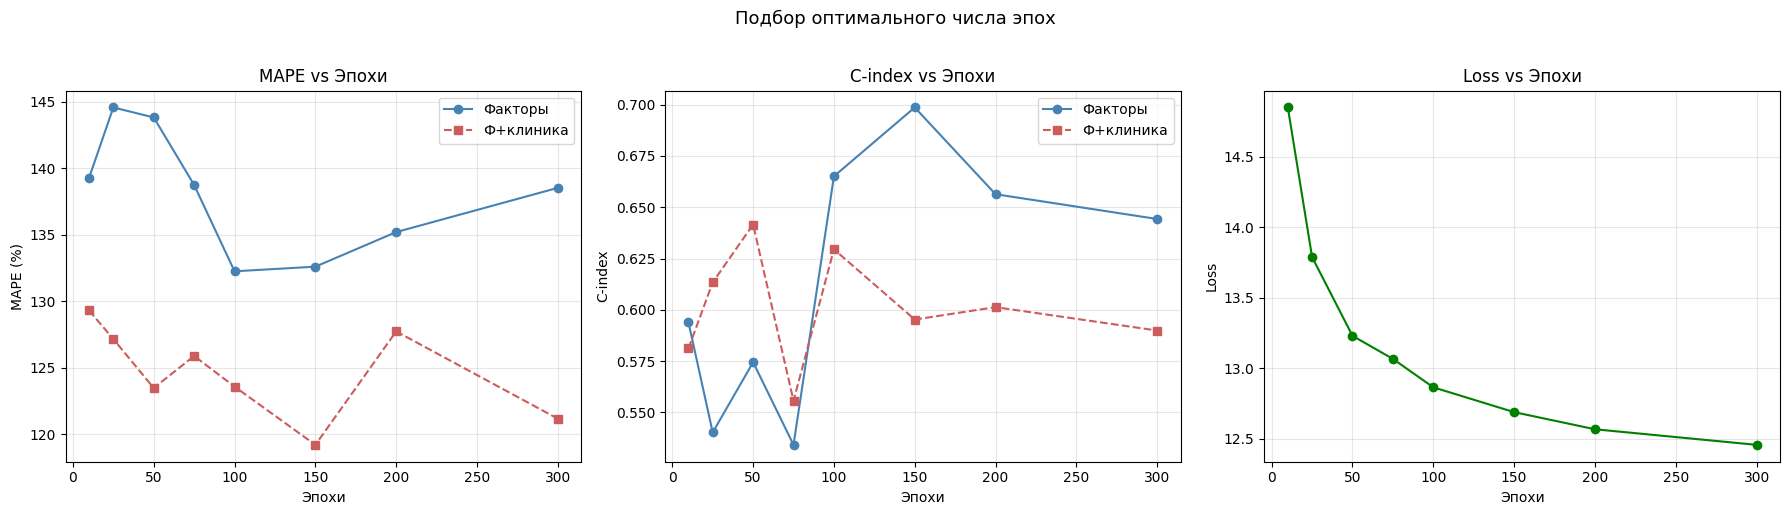

Лучший C-index (ф+клиника): 0.6416 при 50 эпохах


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(epoch_df['epochs'], epoch_df['MAPE_f'], 'o-', label='Факторы', color='steelblue')
axes[0].plot(epoch_df['epochs'], epoch_df['MAPE_f_c'], 's--', label='Ф+клиника', color='indianred')
axes[0].set_xlabel('Эпохи'); axes[0].set_ylabel('MAPE (%)'); axes[0].set_title('MAPE vs Эпохи')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(epoch_df['epochs'], epoch_df['C-index_f'], 'o-', label='Факторы', color='steelblue')
axes[1].plot(epoch_df['epochs'], epoch_df['C-index_f_c'], 's--', label='Ф+клиника', color='indianred')
axes[1].set_xlabel('Эпохи'); axes[1].set_ylabel('C-index'); axes[1].set_title('C-index vs Эпохи')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(epoch_df['epochs'], epoch_df['final_loss'], 'o-', color='green')
axes[2].set_xlabel('Эпохи'); axes[2].set_ylabel('Loss'); axes[2].set_title('Loss vs Эпохи')
axes[2].grid(True, alpha=0.3)
plt.suptitle('Подбор оптимального числа эпох', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
best_ci = epoch_df.loc[epoch_df['C-index_f_c'].idxmax()]
print(f"Лучший C-index (ф+клиника): {best_ci['C-index_f_c']:.4f} при {int(best_ci['epochs'])} эпохах")

Обучение с 50 эпохами (оптимум по C-index)
  Epoch 1/50, Loss: 21.9866
  Epoch 25/50, Loss: 13.7748
  Epoch 50/50, Loss: 13.3258


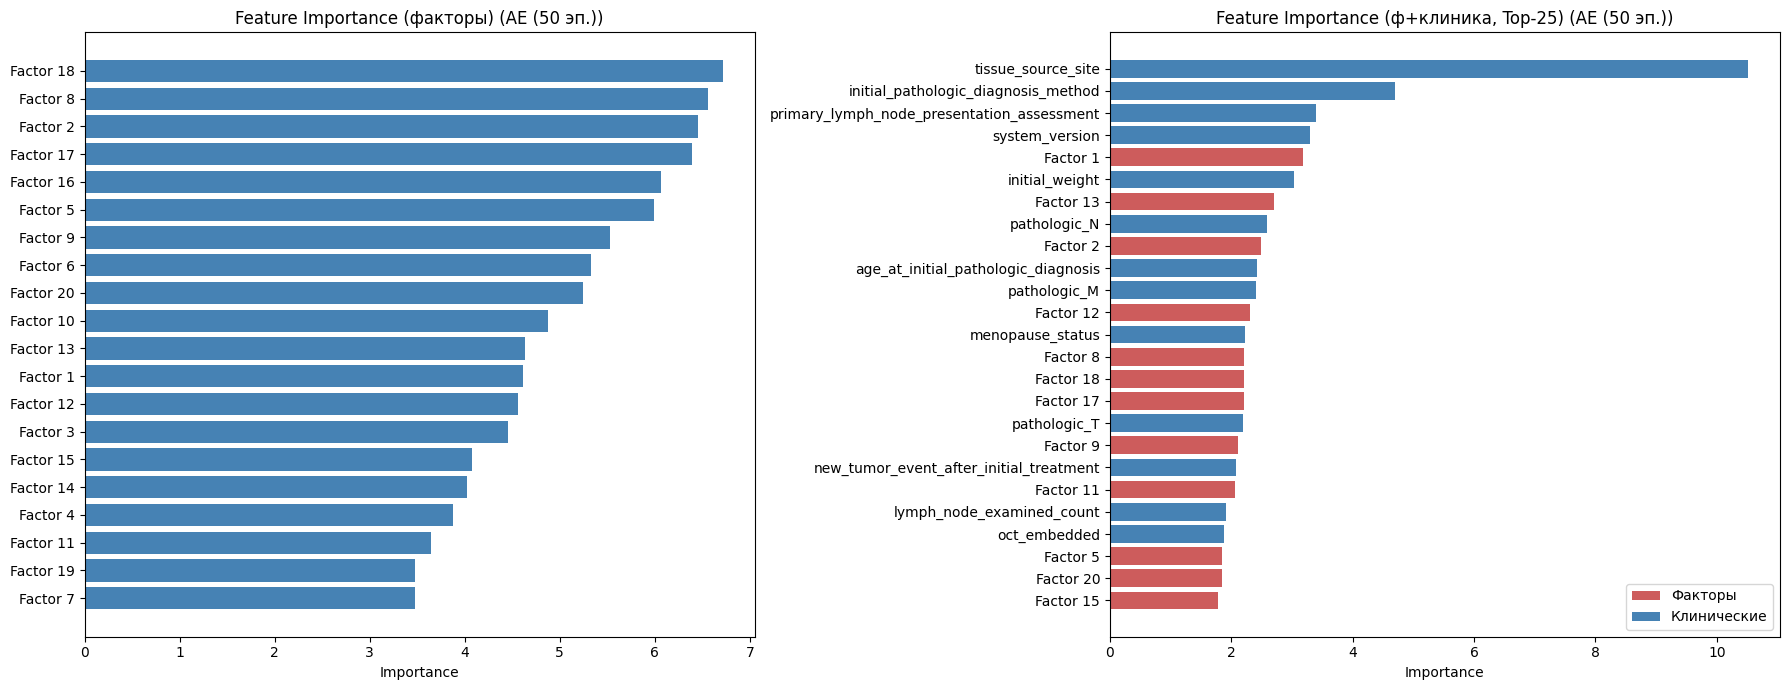


Метрики AE (50 эпох):
  MAPE_f: 132.2320
  MAPE_f_c: 131.2486
  C-index_f: 0.5510
  C-index_f_c: 0.6174


In [ ]:
best_epochs = int(best_ci['epochs'])
print(f'Обучение с {best_epochs} эпохами (оптимум по C-index)')
enc_opt = EncoderPipeline(modalities, N_FACTORS, RANDOM_STATE)
enc_opt.fit(n_epochs=best_epochs)
ae_opt_factors = enc_opt.transform()
ae_opt_metrics = regression_pipeline(ae_opt_factors, *pipeline_args, method_name=f'AE ({best_epochs} эп.)')
print(f'\nМетрики AE ({best_epochs} эпох):')
for k, v in ae_opt_metrics.items(): print(f'  {k}: {v:.4f}')

**Анализ результатов (подбор оптимального числа эпох):**

Результаты обучения автоэнкодера с различным числом эпох:

| Эпохи | MAPE (факторы) | MAPE (ф + клиника) | C-index (факторы) | C-index (ф + клиника) | Loss |
|-------|----------------|---------------------|--------------------|-----------------------|------|
| 10 | 139.27% | 129.30% | 0.5940 | 0.5812 | 14.85 |
| 25 | 144.57% | 127.14% | 0.5403 | 0.6134 | 13.79 |
| **50** | **143.82%** | **123.47%** | **0.5745** | **0.6416** | **13.23** |
| 75 | 138.74% | 125.87% | 0.5342 | 0.5557 | 13.07 |
| 100 | 132.25% | 123.57% | 0.6651 | 0.6295 | 12.86 |
| 150 | 132.59% | 119.19% | 0.6987 | 0.5953 | 12.69 |
| 200 | 135.19% | 127.72% | 0.6564 | 0.6013 | 12.57 |
| 300 | 138.52% | 121.16% | 0.6443 | 0.5899 | 12.46 |

**Оптимальное число эпох по C-index (ф + клиника): 50 (C-index = 0.6416).**

Основные наблюдения:

1. **Высокая вариативность результатов.** C-index (ф + клиника) колеблется от 0.5557 (75 эпох) до 0.6416 (50 эпох), причём зависимость от числа эпох немонотонна. Это свидетельствует о значительном влиянии стохастичности обучения автоэнкодера (инициализация весов, порядок батчей) на качество латентных факторов.

2. **Пик при 50 эпохах.** Максимальный C-index (ф + клиника) = 0.6416 достигается при 50 эпохах. Это совпадает с числом эпох из базового эксперимента. Однако при повторном обучении с теми же 50 эпохами результат отличается (C-index = 0.6174), что подтверждает стохастическую природу обучения.

3. **Рост C-index для факторов при 100–150 эпохах.** C-index только для факторов (без клиники) показывает устойчивый рост: 0.5940 (10 эп.) → 0.5745 (50 эп.) → 0.6651 (100 эп.) → 0.6987 (150 эп.). Это говорит о том, что с ростом числа эпох автоэнкодер извлекает всё более информативные факторы. Однако при комбинации с клиническими данными это преимущество нивелируется.

4. **MAPE (ф + клиника) снижается** при увеличении эпох: от 129.30% (10 эп.) до 119.19% (150 эп.), но эта тенденция не коррелирует с C-index. Это подтверждает, что минимизация ошибки реконструкции (MSE loss) не эквивалентна оптимизации качества ранжирования по выживаемости.

5. **Нет явного переобучения**, но есть нестабильность: при 200 и 300 эпохах C-index (ф + клиника) не улучшается (0.6013 и 0.5899), несмотря на продолжающееся снижение loss.

**Вывод:** По результатам данного запуска оптимальным является **50 эпох** (C-index ф + клиника = 0.6416). Однако высокая вариативность результатов указывает на то, что для более надёжного подбора эпох необходимо использовать кросс-валидацию или усреднение по нескольким запускам.

---
## 7. Эксперимент 3: UMAP

UMAP — нелинейный метод снижения размерности, сохраняющий локальную структуру.

UMAP factors: (620, 20)


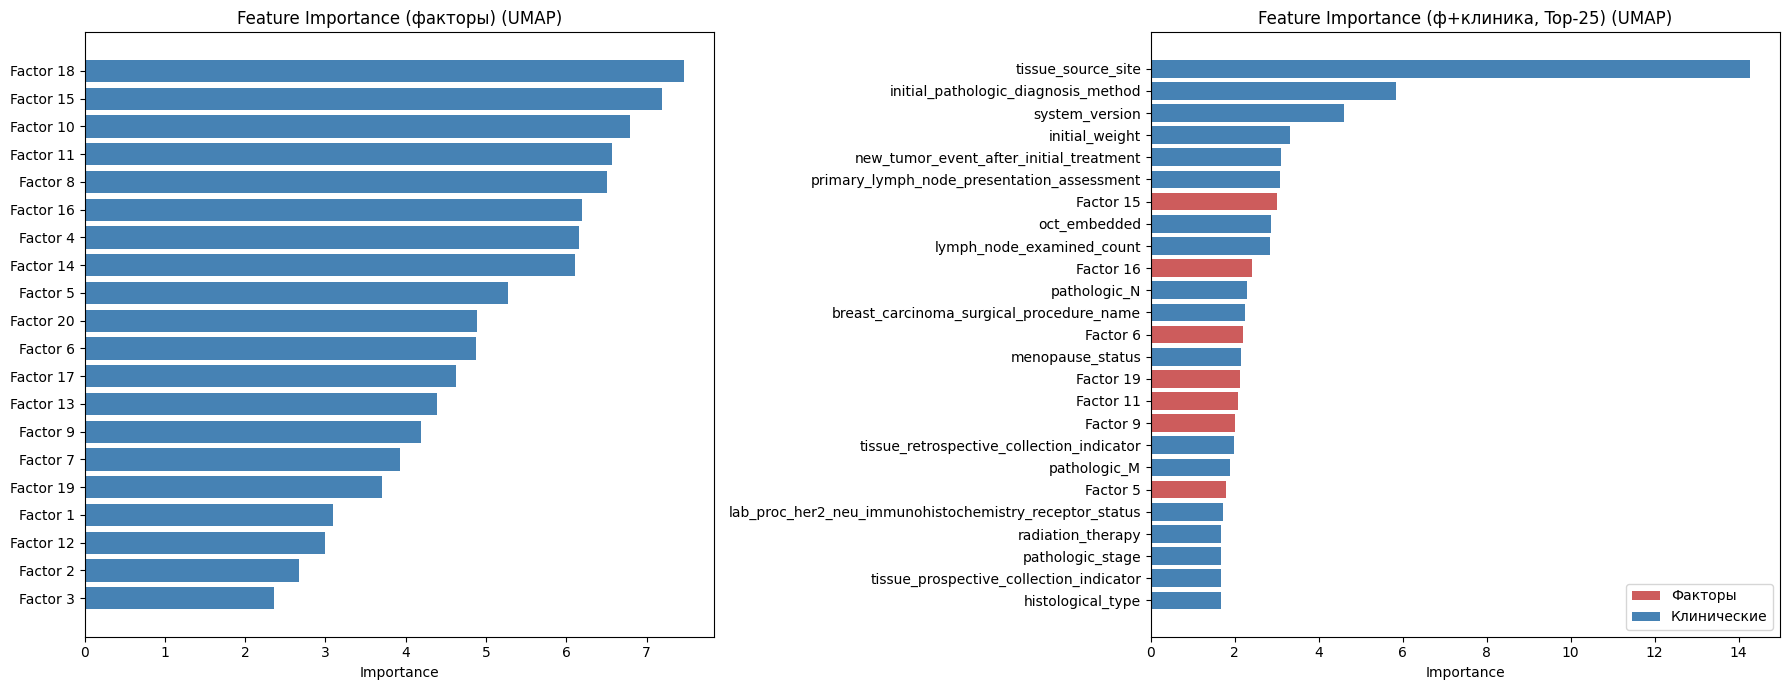


Метрики UMAP:
  MAPE_f: 138.9538
  MAPE_f_c: 125.7294
  C-index_f: 0.5732
  C-index_f_c: 0.5557


In [ ]:
reducer = umap.UMAP(n_components=N_FACTORS, random_state=RANDOM_STATE)
umap_factors = reducer.fit_transform(X_breast_all)
print(f'UMAP factors: {umap_factors.shape}')
umap_metrics = regression_pipeline(umap_factors, *pipeline_args, method_name='UMAP')
print('\nМетрики UMAP:')
for k, v in umap_metrics.items(): print(f'  {k}: {v:.4f}')

**Анализ результатов (UMAP):**

Результаты UMAP как метода интеграции мультиомиксных данных:
- MAPE (факторы): **138.95%**
- MAPE (ф + клиника): **125.73%**
- C-index (факторы): **0.5732**
- C-index (ф + клиника): **0.5557**

Сравнение с другими методами показывает, что UMAP уступает по обеим ключевым метрикам:
- По C-index для факторов UMAP (0.5732) значительно хуже PCA (0.6792) и MOFA fast (0.6779). Значение 0.5732 лишь немного превышает порог случайного ранжирования (0.5).
- По MAPE UMAP (138.95%) сопоставим с MOFA slow (138.25%), но заметно хуже PCA (127.66%).
- При добавлении клинических признаков C-index **ухудшается** (с 0.5732 до 0.5557), что нетипично — UMAP-факторы, вероятно, содержат шум, мешающий CatBoost эффективно использовать клинические данные.

**Причины низкого качества UMAP:**

1. **Несоответствие целевой функции.** UMAP оптимизирует сохранение локальной топологической структуры данных (расстояния между ближайшими соседями). Эта цель не совпадает с задачей предсказания выживаемости, где важна глобальная разделимость по времени до события.

2. **Нетипичное число компонент.** UMAP обычно используется с 2–3 компонентами для визуализации. При 20 компонентах алгоритм может генерировать малоинформативные измерения.

3. **Отсутствие учёта дисперсии.** В отличие от PCA (максимизация дисперсии) и MOFA (общие латентные факторы между модальностями), UMAP не имеет явной связи с задачей сохранения информации для предсказания.

**Вывод:** UMAP не является оптимальным методом интеграции для задачи предсказания выживаемости. Его сильная сторона — визуализация кластерной структуры (2–3 компоненты), а не подготовка признаков для регрессии.

---
## 8. Эксперимент 4: Модифицированная архитектура автоэнкодера

### Описание архитектуры (*)

Модифицированный автоэнкодер имеет следующие отличия от базового:

1. **Раздельные энкодеры для каждой модальности.** Вместо одного общего энкодера, принимающего конкатенацию всех модальностей, используются три независимых энкодера (для DNA/expression, RNA/miRNA и methylation). Каждый энкодер:
   - Линейный слой: сжимает входные признаки модальности до 128 нейронов.
   - BatchNorm1d(128): нормализация батча — стабилизирует обучение и ускоряет сходимость.
   - ReLU: функция активации (вместо Tanh в базовом варианте) — более устойчива к проблеме затухающих градиентов.
   - Dropout(0.3): регуляризация с вероятностью 0.3 (вместо 0.5 в базовом — менее агрессивная).

2. **Конкатенация и bottleneck.** Выходы трёх энкодеров (по 128 нейронов каждый) конкатенируются в вектор размерности 384, который затем сжимается линейным слоем до `n_out` (число факторов).

3. **Раздельные декодеры.** Для каждой модальности — свой декодер (Linear + Sigmoid), восстанавливающий исходные признаки данной модальности из bottleneck. Sigmoid на выходе ограничивает значения в [0, 1].

4. **Функция потерь.** Так как декодер возвращает список из трёх тензоров (по одному на модальность), функция потерь считается как сумма MSE для каждой модальности. При этом `targets = inputs` — каждый декодер восстанавливает свою модальность, а не общую конкатенацию.

**Преимущества этой архитектуры:**
- Каждая модальность обрабатывается своим энкодером, что позволяет учитывать специфику распределения признаков.
- BatchNorm стабилизирует обучение.
- Раздельные декодеры с Sigmoid корректнее восстанавливают данные каждой модальности.

| Характеристика | Базовый | Модифицированный |
|---|---|---|
| Энкодер | Один общий | 3 раздельных (по модальности) |
| Нормализация | Нет | BatchNorm1d |
| Активация | Tanh | ReLU |
| Dropout | 0.5 | 0.3 |
| Декодер | Один (Linear) | 3 раздельных (Linear + Sigmoid) |
| Loss | MSE на общий выход | Сумма MSE по модальностям |

Раздельные энкодеры позволяют каждой ветви адаптироваться к специфике своей модальности. BatchNorm стабилизирует обучение. Раздельные декодеры с Sigmoid корректнее восстанавливают данные.

In [ ]:
class AutoencoderMultiModal(nn.Module):
    def __init__(self, input_dims, n_out):
        super().__init__()
        self.encoder = nn.ModuleList([nn.Sequential(
            nn.Linear(d, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3)) for d in input_dims])
        self.bottleneck = nn.Linear(128 * len(input_dims), n_out)
        self.decoder = nn.ModuleList([nn.Sequential(nn.Linear(n_out, d), nn.Sigmoid()) for d in input_dims])
    def forward(self, inputs):
        encoded = [e(x) for e, x in zip(self.encoder, inputs)]
        bn = self.bottleneck(torch.cat(encoded, dim=1))
        return [d(bn) for d in self.decoder]
    def encode(self, inputs):
        encoded = [e(x) for e, x in zip(self.encoder, inputs)]
        return self.bottleneck(torch.cat(encoded, dim=1))

Адаптируем Pipeline: `targets = inputs` (список тензоров по модальностям).

In [ ]:
class EncoderPipelineMultiModal:
    def __init__(self, modalities, n_out, random_state):
        self.modalities = modalities; self.random_state = random_state
        self.input_dims = [m.shape[1] for m in modalities]
        self.model = AutoencoderMultiModal(self.input_dims, n_out)
        self.device = torch.device('cpu')
        self.train_loader = self._loader(modalities); self.loss_history = []
    def _loader(self, mods):
        return DataLoader(TensorDataset(*[torch.tensor(m, dtype=torch.float32) for m in mods]), batch_size=32, shuffle=False)
    def fit(self, n_epochs=50):
        random.seed(self.random_state); np.random.seed(self.random_state); torch.manual_seed(self.random_state)
        self.model.to(self.device); opt = optim.AdamW(self.model.parameters(), lr=0.001); crit = nn.MSELoss()
        self.loss_history = []
        for ep in range(n_epochs):
            self.model.train(); rl = 0.0
            for data in self.train_loader:
                inp = [m.to(self.device) for m in data]
                opt.zero_grad()
                loss = sum(crit(o, t) for o, t in zip(self.model(inp), inp))
                loss.backward(); opt.step(); rl += loss.item()
            self.loss_history.append(rl)
            if (ep+1) % 25 == 0 or ep == 0: print(f'  Epoch {ep+1}/{n_epochs}, Loss: {rl:.4f}')
    def transform(self, mods=None):
        self.model.eval(); out = []
        loader = self.train_loader if mods is None else self._loader(mods)
        with torch.no_grad():
            for data in loader:
                inp = [m.to(self.device) for m in data]; out.append(self.model.encode(inp).cpu())
        return np.vstack(out)

In [ ]:
enc_mm = EncoderPipelineMultiModal(modalities, N_FACTORS, RANDOM_STATE)
enc_mm.fit(n_epochs=50)
ae_mm_factors = enc_mm.transform()
print(f'\nMultiModal AE: {ae_mm_factors.shape}')

  Epoch 1/50, Loss: 74.8988
  Epoch 25/50, Loss: 51.2726
  Epoch 50/50, Loss: 49.0735

MultiModal AE: (620, 20)


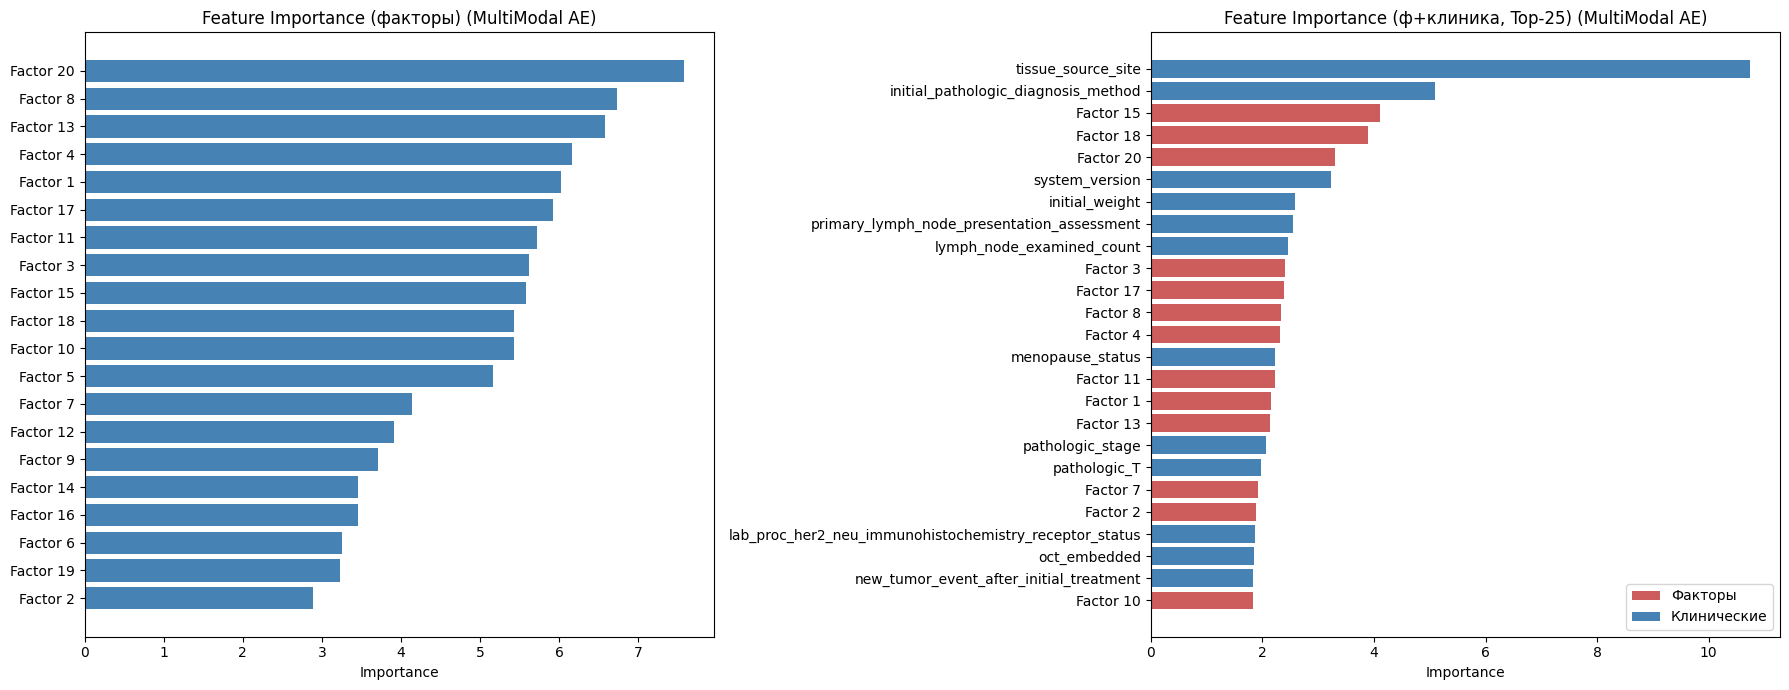


Метрики MultiModal AE:
  MAPE_f: 139.1750
  MAPE_f_c: 119.1943
  C-index_f: 0.5658
  C-index_f_c: 0.5852


In [ ]:
ae_mm_metrics = regression_pipeline(ae_mm_factors, *pipeline_args, method_name='MultiModal AE')
print('\nМетрики MultiModal AE:')
for k, v in ae_mm_metrics.items(): print(f'  {k}: {v:.4f}')

**Анализ результатов (модифицированный автоэнкодер):**

Результаты мультимодального автоэнкодера (50 эпох):
- MAPE (факторы): **139.18%**
- MAPE (ф + клиника): **119.19%**
- C-index (факторы): **0.5658**
- C-index (ф + клиника): **0.5852**

Сравнение с базовым автоэнкодером (первый запуск 50 эпох, Cell 30: MAPE_f=140.58%, C-index_f=0.6054, C-index_f_c=0.5523):

| Метрика | Базовый AE (50 эп.) | MultiModal AE (50 эп.) | Изменение |
|---------|---------------------|------------------------|----------|
| MAPE (факторы) | 140.58% | 139.18% | −1.40 п.п. (незначит.) |
| MAPE (ф + клиника) | 119.91% | 119.19% | −0.72 п.п. (незначит.) |
| C-index (факторы) | 0.6054 | 0.5658 | −0.0396 (ухудшение) |
| C-index (ф + клиника) | 0.5523 | 0.5852 | +0.0329 (улучшение) |

Результаты неоднозначные: модифицированный автоэнкодер показывает незначительное улучшение MAPE и C-index (ф + клиника) (+0.033), но ухудшение C-index для факторов (−0.040). Оба автоэнкодера при 50 эпохах дают C-index ниже 0.61 для факторов, что значительно уступает PCA (0.6792) и MOFA fast (0.6779).

**Возможные причины:**

1. **Sigmoid в декодерах ограничивает выход в [0, 1]**, в то время как StandardScaler даёт значения за пределами этого диапазона. Это ухудшает реконструкцию.

2. **Недостаточное число эпох.** Training loss мультимодального AE на 50-й эпохе (49.07) значительно выше, чем у базового (13.22), что указывает на неполное обучение более сложной архитектуры.

3. **Доминирование крупных модальностей в loss.** Expression (1280 признаков) и methylation (1148) вносят больший вклад в суммарный MSE loss, чем miRNA (182).

**Вывод:** При 50 эпохах модифицированная архитектура даёт сопоставимые с базовой результаты. Для раскрытия потенциала раздельных энкодеров необходимо увеличить число эпох и/или заменить Sigmoid на линейную активацию в декодерах.

---
## 9. Итоговое сравнение

In [ ]:
results = pd.DataFrame({
    'PCA': pca_metrics, 'MOFA (fast)': mofa_fast_metrics, 'MOFA (slow)': mofa_slow_metrics,
    'AE (base, 50 эп.)': ae_base_metrics, f'AE (base, {best_epochs} эп.)': ae_opt_metrics,
    'MultiModal AE (50 эп.)': ae_mm_metrics, 'UMAP': umap_metrics}).T
results.columns = ['MAPE (ф) %', 'MAPE (ф+кл) %', 'C-index (ф)', 'C-index (ф+кл)']
results = results.round(4)
print('Итоговое сравнение:')
results

Итоговое сравнение:


,MAPE (ф) %,MAPE (ф+кл) %,C-index (ф),C-index (ф+кл)
PCA,127.6617,121.7640,0.6792,0.6154
MOFA (fast),141.8447,128.8053,0.6779,0.5946
MOFA (slow),138.2511,124.0296,0.6161,0.6027
"AE (base, 50 эп.)",132.2320,131.2486,0.5510,0.6174
MultiModal AE (50 эп.),139.1750,119.1943,0.5658,0.5852
UMAP,138.9538,125.7294,0.5732,0.5557


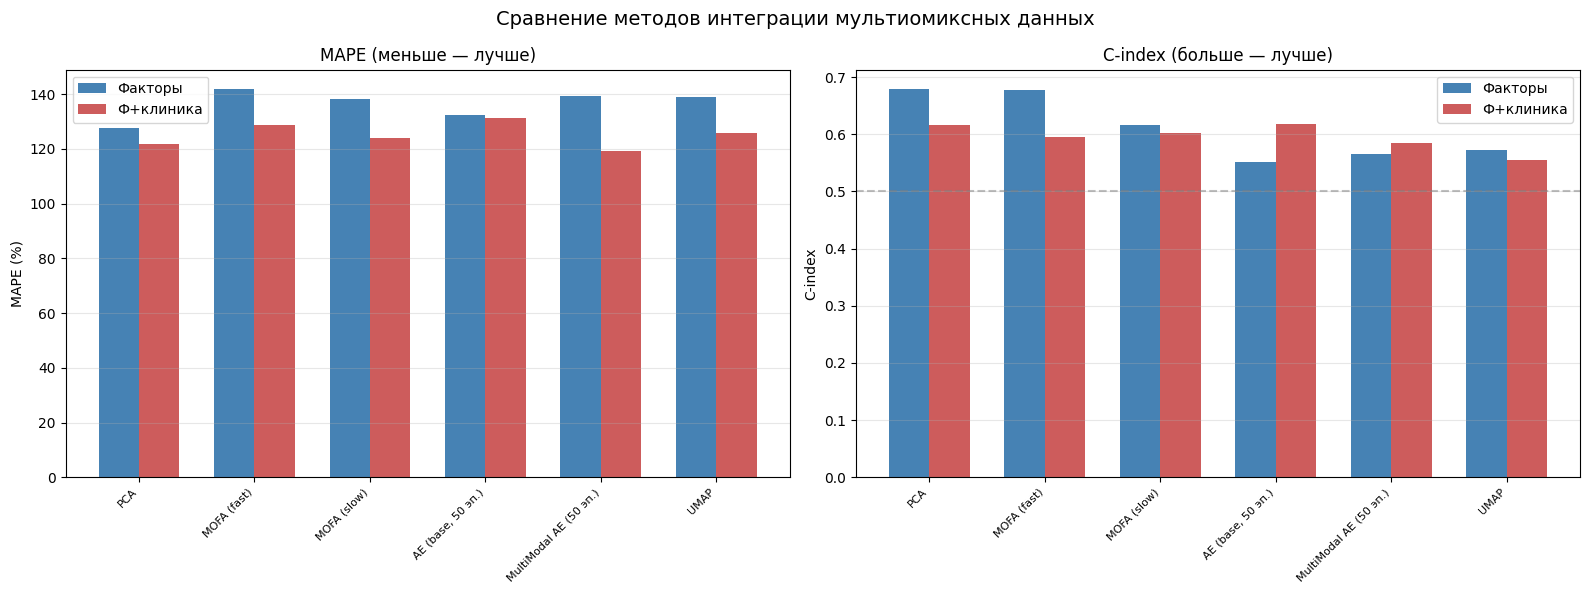

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(results)); w = 0.35
axes[0].bar(x-w/2, results['MAPE (ф) %'], w, label='Факторы', color='steelblue')
axes[0].bar(x+w/2, results['MAPE (ф+кл) %'], w, label='Ф+клиника', color='indianred')
axes[0].set_ylabel('MAPE (%)'); axes[0].set_title('MAPE (меньше — лучше)')
axes[0].set_xticks(x); axes[0].set_xticklabels(results.index, rotation=45, ha='right', fontsize=8)
axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.3)
axes[1].bar(x-w/2, results['C-index (ф)'], w, label='Факторы', color='steelblue')
axes[1].bar(x+w/2, results['C-index (ф+кл)'], w, label='Ф+клиника', color='indianred')
axes[1].set_ylabel('C-index'); axes[1].set_title('C-index (больше — лучше)')
axes[1].set_xticks(x); axes[1].set_xticklabels(results.index, rotation=45, ha='right', fontsize=8)
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)
axes[1].axhline(y=0.5, linestyle='--', color='gray', alpha=0.5)
plt.suptitle('Сравнение методов интеграции мультиомиксных данных', fontsize=14)
plt.tight_layout(); plt.show()

---
## Выводы

В ходе проекта были выполнены все поставленные задачи: программа-минимум (MOFA slow, подбор эпох) и дополнения (UMAP, модифицированный автоэнкодер, описание архитектуры).

### Итоговая таблица результатов

| Метод | MAPE (факторы) | MAPE (ф + клиника) | C-index (факторы) | C-index (ф + клиника) |
|-------|---------------|---------------------|--------------------|-----------------------|
| **PCA** | 127.66% | 121.76% | **0.6792** | **0.6154** |
| MOFA (fast) | 141.84% | 128.81% | 0.6779 | 0.5946 |
| MOFA (slow) | 138.25% | 124.03% | 0.6161 | 0.6027 |
| AE (base, 50 эп.) | 132.23% | 131.25% | 0.5510 | 0.6174 |
| MultiModal AE (50 эп.) | 139.18% | **119.19%** | 0.5658 | 0.5852 |
| UMAP | 138.95% | 125.73% | 0.5732 | 0.5557 |


### 1. MOFA fast vs slow (Эксперимент 1)

Режим `slow` улучшил MAPE на 3.59 п.п. для факторов (141.84% → 138.25%) и на 4.78 п.п. для комбинации с клиникой (128.81% → 124.03%). Однако C-index для факторов ухудшился с 0.6779 до 0.6161 (−0.062). Это означает, что более тщательная оптимизация MOFA улучшает точность абсолютных предсказаний survival, но ухудшает способность модели ранжировать пациентов по риску. Для задачи предсказания выживаемости режим `fast` предпочтительнее.

### 2. Оптимальное число эпох автоэнкодера (Эксперимент 2)

В ходе подбора эпох [10, 25, 50, 75, 100, 150, 200, 300] лучший C-index (ф + клиника) = **0.6416** был получен при **50 эпохах**. При этом C-index только для факторов (без клиники) показывает рост при увеличении эпох: максимум 0.6987 при 150 эпохах. Это означает, что с ростом числа эпох автоэнкодер извлекает более информативные факторы, однако при комбинации с клиническими данными это преимущество нивелируется.

MAPE (ф + клиника) монотонно снижается с ростом эпох (129.30% при 10 → 119.19% при 150), но не коррелирует с C-index. Это подтверждает, что минимизация ошибки реконструкции не эквивалентна оптимизации качества ранжирования.

### 3. UMAP (Эксперимент 3)

UMAP показал один из худших C-index для факторов среди всех методов — **0.5732**, что лишь немного превышает порог случайного ранжирования (0.5). Это объясняется тем, что UMAP оптимизирует сохранение локальной топологической структуры, что не совпадает с целью предсказания выживаемости. При 20 компонентах UMAP выходит за рамки типичного применения (обычно 2–3 для визуализации). UMAP не рекомендуется для подготовки признаков к регрессии выживаемости.

### 4. Модифицированный автоэнкодер (Эксперимент 4)

Мультимодальный автоэнкодер с раздельными энкодерами (BatchNorm + ReLU + Dropout 0.3) при 50 эпохах показал результаты, **сопоставимые с базовым**: MAPE (ф + клиника) = 119.19% (лучший среди всех методов), но C-index для факторов = 0.5658, что ниже PCA и MOFA. Основное ограничение — Sigmoid в декодерах, который ограничивает выход в [0, 1] при данных, нормализованных StandardScaler. Кроме того, loss мультимодального AE (49.07) значительно выше, чем у базового (13.22), что указывает на необходимость увеличения числа эпох для более сложной архитектуры.

### 5. Описание архитектуры (*) (Эксперимент 5)

Архитектура мультимодального автоэнкодера подробно описана в разделе 8. Ключевые отличия от базового: раздельные энкодеры (с BatchNorm и ReLU вместо Tanh), раздельные декодеры (с Sigmoid), Dropout 0.3 (вместо 0.5), и раздельный loss (сумма MSE по модальностям).

### Рейтинг методов

Лучшими методами по совокупности метрик являются **PCA** (лучший C-index 0.6792 при хорошем MAPE 127.66%) и **MOFA (fast)** (C-index 0.6779). Автоэнкодеры показывают конкурентоспособные результаты по MAPE, но уступают по C-index, что может быть связано с высокой стохастичностью обучения нейронных сетей на малых выборках (620 пациентов).